In [1]:
import os
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
def get_metric_value(candidate: dict, area: str, metric: str):
    """Safely retrieve a nested metric value, handling None and NaN cases."""
    try:
        val = candidate.get(area, {}).get(metric, None)
        if val is None or val == "None" or (isinstance(val, float) and np.isnan(val)):
            return None
        return float(val)
    except (AttributeError, ValueError, TypeError):
        return None

In [3]:
def analyze_area_sigma_distribution(
    all_groups, 
    area_name='edit_area',      # Specify the target area for analysis
    metric_name='lpips',        # Specify the evaluation metric
    direction='lower',          # 'higher' (larger is better, e.g., SSIM) or 'lower' (smaller is better, e.g., LPIPS)
    bin_width=0.1
):
    """
    Compute and visualize the Sigma (Z-score) distribution of samples within each group
    for a given area and metric.

    Additionally, provide recommended thresholds for identifying elite and failure samples.
    """
    print(f"=========================================")
    print(f"🔍 Analyzing: {area_name} -> {metric_name} ({direction} better)")
    print(f"=========================================")
    
    z_scores = []
    
    # --- 1. Data processing: compute Z-score for each sample ---
    for group in all_groups:
        # Collect all valid values within the current group
        valid_vals = []
        for cand in group:
            val = get_metric_value(cand, area_name, metric_name)
            if val is not None:
                valid_vals.append(val)
                
        # Skip if fewer than 2 valid samples (cannot compute mean/std)
        if len(valid_vals) < 2: 
            continue
            
        vals = np.array(valid_vals, dtype=float)
        
        # If lower is better (e.g., LPIPS), negate values so that
        # the right side of the distribution always indicates better performance
        # Supports both string ('lower') and numeric (-1) formats
        if direction == 'lower' or direction == -1:
            vals = -vals
            
        mu = np.mean(vals)
        std = np.std(vals)
        
        # Skip groups with extremely small variance (tie groups)
        if std < 1e-6: 
            continue
            
        # Compute Z-Score: (x - mean) / std
        group_z_scores = (vals - mu) / std
        z_scores.extend(group_z_scores)
        
    z_scores = np.array(z_scores)
    
    if len(z_scores) == 0:
        print(f"[{area_name} - {metric_name}] No valid data available for analysis "
              f"(all groups may have zero variance or None values).")
        return

    # --- 2. Statistical analysis: recommend elite and failure thresholds ---
    print(f"=== {area_name} : {metric_name} Sigma Distribution Statistics (direction: {direction}) ===")
    print(f"Total valid samples: {len(z_scores)}")
    print(f"Mean of Z-scores (should be ~0): {np.mean(z_scores):.4f}")
    print(f"Std of Z-scores (should be ~1): {np.std(z_scores):.4f}")
    
    print("\n--- 🌟 Elite Threshold Recommendations (Right Tail) ---")
    # We focus on the right tail to find samples with extremely good performance
    right_percentiles = [70, 80, 85, 90, 95]
    for p in right_percentiles:
        thresh = np.percentile(z_scores, p)
        print(f"Top {100-p:2d}% of elite samples fall in the > {thresh:5.2f} σ region (recommended threshold_elite ≈ {thresh:.2f})")

    print("\n--- ⚠️ Failure Threshold Recommendations (Left Tail) ---")
    # We focus on the left tail to find samples with extremely poor performance
    left_percentiles = [5, 10, 15, 20, 30]
    for p in left_percentiles:
        thresh = np.percentile(z_scores, p)
        print(f"Bottom {p:2d}% of failure samples fall in the < {thresh:5.2f} σ region (recommended threshold_failure ≈ {thresh:.2f})")

    # --- 3. Visualization: plot histogram ---
    plt.figure(figsize=(12, 6))
    
    min_z, max_z = np.min(z_scores), np.max(z_scores)
    # Clip extreme outliers for better visualization
    plot_min = max(np.floor(min_z), -5)
    plot_max = min(np.ceil(max_z), 5)
    
    bins = np.arange(plot_min, plot_max + bin_width, bin_width)
    
    # Histogram + KDE
    sns.histplot(z_scores, bins=bins, kde=True, color='skyblue', edgecolor='black', stat='count')
    
    # Reference lines (mean and standard deviation levels)
    plt.axvline(0, color='red', linestyle='-', linewidth=2, label='Group Mean (0σ)')
    plt.axvline(0.5, color='green', linestyle='--', alpha=0.8, label='0.5σ (Good)')
    plt.axvline(-0.5, color='purple', linestyle='--', alpha=0.8, label='-0.5σ (Bad)')
    plt.axvline(1.0, color='orange', linestyle='-.', alpha=0.8, label='1.0σ (Elite)')
    plt.axvline(-1.0, color='brown', linestyle='-.', alpha=0.8, label='-1.0σ (Failure)')
    
    plt.title(f'Z-Score Distribution for "{area_name} : {metric_name}"', fontsize=14, pad=15)
    plt.xlabel(f'Sigma (Standard Deviations from Group Mean)\n➡️ Right is Better (Elite), Left is Worse (Failure) ⬅️', fontsize=12)
    plt.ylabel('Count of Candidates', fontsize=12)
    plt.legend(loc='upper right')
    plt.grid(axis='y', alpha=0.3)
    
    # Refine x-axis ticks
    plt.xticks(np.arange(int(plot_min), int(plot_max)+1, 0.5))
    
    plt.tight_layout()
    plt.show()

In [7]:
task_file = "/data/open_edit/data/c_annotated_group_data/motion_change_grouped.jsonl"
data = [
    json.loads(line) for line in open(task_file)
]
cleaned_data = []
for group in data:
    try:
        cleaned_group = [item for item in group['results']]
        cleaned_data.append(cleaned_group)
    except:
        print("Error processing group, skipping.")

Analysis Task: /data/open_edit/data/c_annotated_group_data/motion_change_grouped.jsonl | Area: edit_area | Metric: face_ID_sim | Direction: higher
🔍 Analyzing: edit_area -> face_ID_sim (higher better)
=== edit_area : face_ID_sim Sigma Distribution Statistics (direction: higher) ===
Total valid samples: 30417
Mean of Z-scores (should be ~0): -0.0000
Std of Z-scores (should be ~1): 1.0000

--- 🌟 Elite Threshold Recommendations (Right Tail) ---
Top 30% of elite samples fall in the >  0.63 σ region (recommended threshold_elite ≈ 0.63)
Top 20% of elite samples fall in the >  0.81 σ region (recommended threshold_elite ≈ 0.81)
Top 15% of elite samples fall in the >  0.92 σ region (recommended threshold_elite ≈ 0.92)
Top 10% of elite samples fall in the >  1.08 σ region (recommended threshold_elite ≈ 1.08)
Top  5% of elite samples fall in the >  1.34 σ region (recommended threshold_elite ≈ 1.34)

--- ⚠️ Failure Threshold Recommendations (Left Tail) ---
Bottom  5% of failure samples fall in the

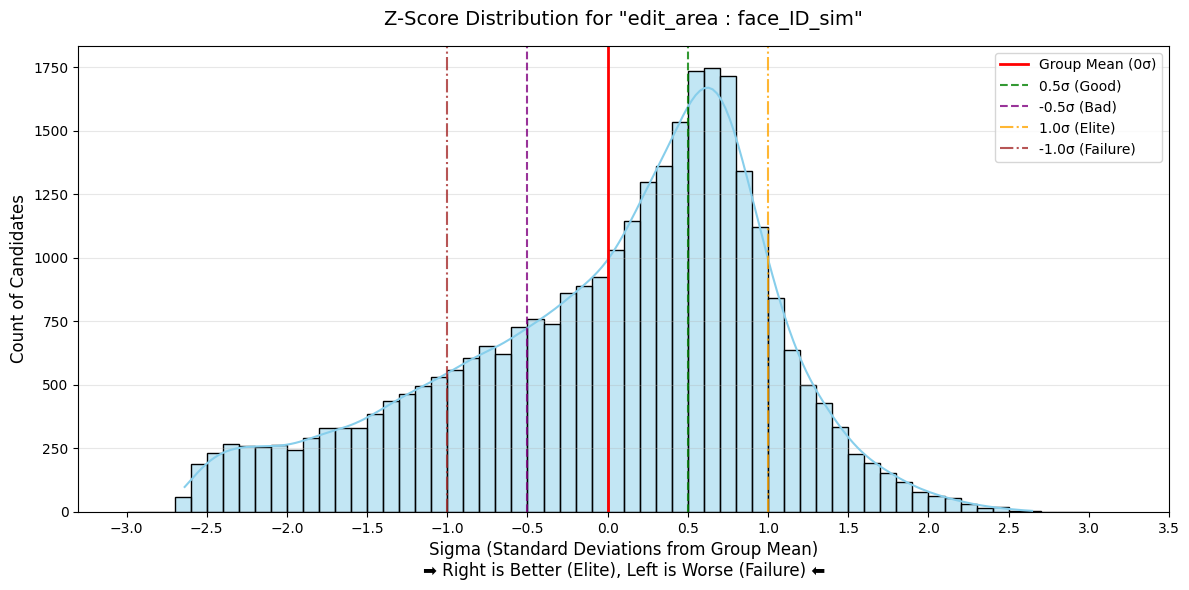

In [8]:
area_name = 'edit_area'
metric_name = 'face_ID_sim'
direction = 'higher'

print(f"Analysis Task: {task_file} | Area: {area_name} | Metric: {metric_name} | Direction: {direction}")
analyze_area_sigma_distribution(
    cleaned_data,
    area_name=area_name,
    metric_name=metric_name,
    direction=direction
)